In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Load dataset
df = pd.read_csv(r"D:\ecommerce-analysis\data\Amazon Sale Report.csv", low_memory=False)

# Show first rows
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [17]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [19]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Remove missing values
df = df.dropna()

# Rename columns
df = df.rename(columns={'Qty': 'Quantity', 'Amount': 'Sales'})

C:\Users\HP\AppData\Local\Temp\ipykernel_29780\4008392028.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)


In [23]:
# Extract Month
df['Month'] = df['Date'].dt.month

In [25]:
#ANALYSIS
#Total Revenue
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 13046818.0


In [27]:
#Category Analysis
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.head(10)

Category
Set              5919897.0
Western Dress    3318232.0
kurta            2891562.0
Top               721354.0
Ethnic Dress      102085.0
Blouse             42488.0
Bottom             41541.0
Saree               9659.0
Name: Sales, dtype: float64

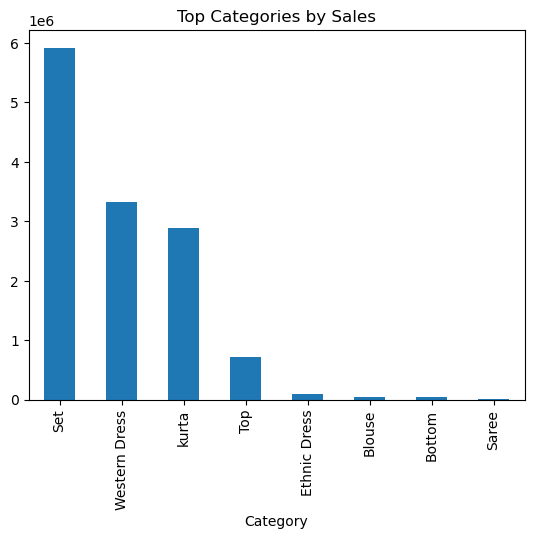

In [29]:
#Plot
category_sales.head(10).plot(kind='bar')
plt.title("Top Categories by Sales")
plt.show()

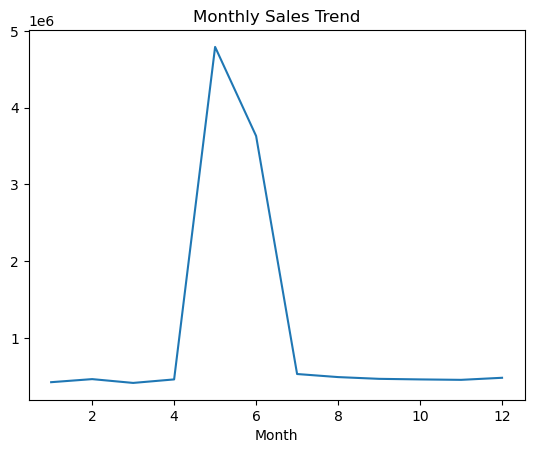

In [31]:
#Monthly Trend
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

In [33]:
#Fulfillment Analysis
fulfillment_sales = df.groupby('Fulfilment')['Sales'].sum()

fulfillment_sales

Fulfilment
Merchant    13046818.0
Name: Sales, dtype: float64

In [35]:
#Top Products
top_products = df.groupby('SKU')['Sales'].sum().sort_values(ascending=False)

top_products.head()

SKU
JNE3797-KR-L      289500.0
JNE3797-KR-M      269095.0
JNE3797-KR-S      201541.0
JNE3797-KR-XL     195101.0
SET183-KR-DH-M    134343.0
Name: Sales, dtype: float64

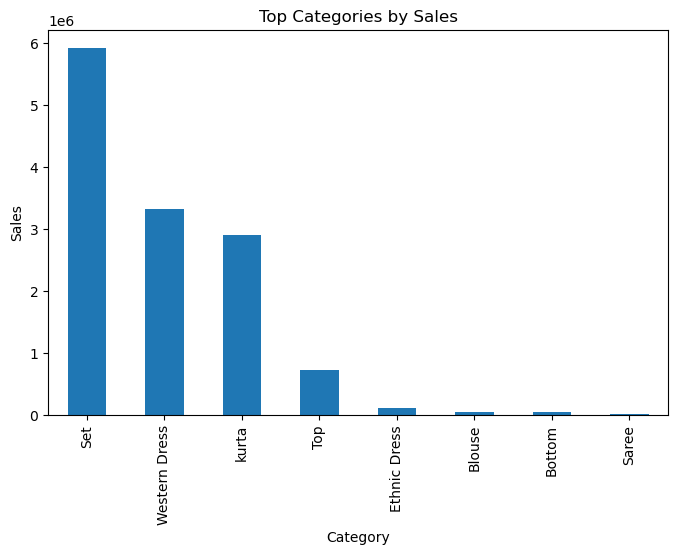

In [37]:
# Plot Category Sales
category_sales.head(10).plot(kind='bar', figsize=(8,5))
plt.title("Top Categories by Sales")
plt.ylabel("Sales")
plt.xlabel("Category")

# Save image in 'images' folder
plt.savefig('../images/category_sales.png')  # <-- important
plt.show()

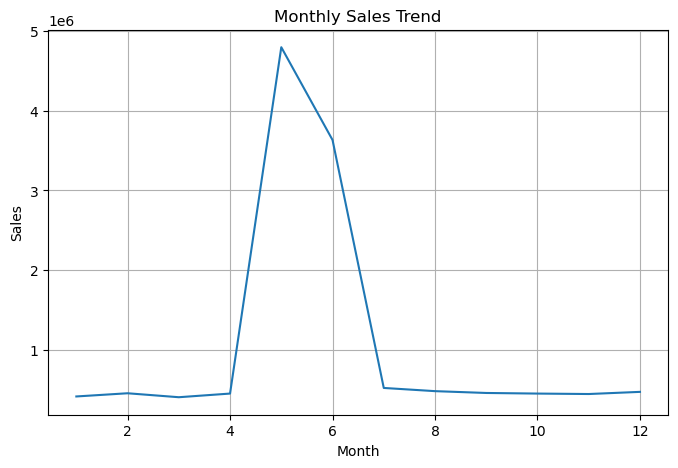

In [39]:
monthly_sales.plot(kind='line', figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.grid(True)

# Save image
plt.savefig('../images/monthly_sales.png')
plt.show()